# Learning a swing up policy using reinforcement learning (Vanilla Q-learning)
by TimJanssen66

### General understanding
I'm using Vanilla (Tabular) Q-learning ...

## Table of contents

1. <a href="#Training-on-simulator">Training on simulator</a>
2. <a href="#Testing-on-simulator">Testing on simulator</a>
3. <a href="#Testing-on-setup">Testing on setup</a>
4. <a href="#Exercise-6:-Design-Assignment-Environment.">Exercise 6: Design Assignment Environment</a>


In [5]:
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk
import pickle
import time
import matplotlib.pyplot as plt

In [6]:
# --- 1. Compatibility & Action Wrappers ---
class CompatibilityWrapper(gym.Wrapper):
    def reset(self, *, seed=None, options=None):
        obs = self.env.reset()
        if not isinstance(obs, tuple):
            return obs, {}
        elif len(obs) == 2 and isinstance(obs[1], dict):
            return obs
        else:
            return obs, {}

    def step(self, action):
        result = self.env.step(action)
        if len(result) == 4:
            obs, reward, done, info = result
            return obs, reward, done, False, info
        return result

class DiscretizeAction(gym.ActionWrapper):
    def __init__(self, env, discrete_actions):
        super().__init__(env)
        self.discrete_actions = np.array(discrete_actions)
        self.action_space = gym.spaces.Discrete(len(self.discrete_actions))

    def action(self, act_idx):
        return float(self.discrete_actions[act_idx])

# --- Sensor Noise Wrapper ---
class SensorNoiseWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_std_theta, noise_std_omega):
        super().__init__(env)
        self.noise_std_theta = noise_std_theta
        self.noise_std_omega = noise_std_omega

    def observation(self, obs):
        noisy_obs = np.copy(obs)
        # Inject Gaussian noise into the measurements
        noisy_obs[0] += np.random.normal(0, self.noise_std_theta)
        noisy_obs[1] += np.random.normal(0, self.noise_std_omega)
        return noisy_obs

In [7]:
# --- 3. NEW: Low Pass Filter Wrapper ---
class LowPassFilterWrapper(gym.Wrapper):
    def __init__(self, env, alpha_theta=0.8, alpha_omega=0.15):
        super().__init__(env)
        self.alpha_theta = alpha_theta
        self.alpha_omega = alpha_omega
        self.filtered_obs = np.zeros(2)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.filtered_obs = np.array(obs, dtype=np.float32)
        return self.filtered_obs.copy(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Filter Velocity (Standard EMA)
        self.filtered_obs[1] = self.alpha_omega * obs[1] + (1 - self.alpha_omega) * self.filtered_obs[1]
        
        # Filter Position (Must use circular math to avoid wrapping errors at pi/-pi)
        # Convert angle to vector [cos(th), sin(th)], filter the vector, then atan2 it back
        prev_th = self.filtered_obs[0]
        new_th = obs[0]
        
        # Moving average in 2D Euclidean space
        avg_x = self.alpha_theta * np.cos(new_th) + (1 - self.alpha_theta) * np.cos(prev_th)
        avg_y = self.alpha_theta * np.sin(new_th) + (1 - self.alpha_theta) * np.sin(prev_th)
        self.filtered_obs[0] = np.arctan2(avg_y, avg_x)

        return self.filtered_obs.copy(), reward, terminated, truncated, info

# class TriangularFeatureExtractor:
#     # Updated to 41x31 grid and 66.0 max_omega based on System ID
#     def __init__(self, n_theta=41, n_omega=31, max_omega=60.0):
#         x_th = np.linspace(-1, 1, n_theta)
#         self.c_th = np.sign(x_th) * (np.abs(x_th)**1.5) * np.pi 
#         self.c_om = np.linspace(-max_omega, max_omega, n_omega)
        
#         self.w_th = np.diff(self.c_th)
#         self.w_th = np.append(self.w_th, self.w_th[-1]) * 1.2 
#         self.w_om = (self.c_om[1] - self.c_om[0]) * 1.2
        
#         self.n_features = n_theta * n_omega

class TriangularFeatureExtractor:
    def __init__(self, n_theta=41, n_omega=31, max_omega=60.0):
        x_th = np.linspace(-1, 1, n_theta)
        self.c_th = np.sign(x_th) * (np.abs(x_th)**1.5) * np.pi 
        
        # FIX: Apply non-linear mapping to velocity to increase phase-space resolution at low speeds
        x_om = np.linspace(-1, 1, n_omega)
        self.c_om = np.sign(x_om) * (np.abs(x_om)**1.5) * max_omega
        
        self.w_th = np.diff(self.c_th)
        self.w_th = np.append(self.w_th, self.w_th[-1]) * 1.2 
        
        # FIX: Velocity widths must now be an array to handle the variable non-linear spacing
        self.w_om = np.diff(self.c_om)
        self.w_om = np.append(self.w_om, self.w_om[-1]) * 1.2
        
        self.n_features = n_theta * n_omega

    def wrap_angle(self, angle):
        return ((angle + np.pi) % (2 * np.pi)) - np.pi

    def get_features(self, obs):
        th_error = self.wrap_angle(obs[0] - np.pi)
        omega = np.clip(obs[1], self.c_om[0], self.c_om[-1])
        
        act_th = np.maximum(0, 1.0 - np.abs(th_error - self.c_th) / self.w_th)
        act_om = np.maximum(0, 1.0 - np.abs(omega - self.c_om) / self.w_om)
        
        features = np.outer(act_th, act_om).flatten()
        return features

## Training on simulator

In [53]:
# # Training on simulator
# # --- 3. Q-Learning with SGD ---
# # def get_hybrid_reward(obs, action_voltage):
# #     # obs[0] is angle. Assume pi is top.
# #     th_error = (((obs[0] - np.pi) + np.pi) % (2 * np.pi)) - np.pi
# #     omega = obs[1]
    
# #     # RE-TUNED WEIGHTS
# #     c1 = 5.0    # Position is still the most important
# #     c2 = 0.002  # Drastically reduced! (0.002 * 60^2 = 7.2 max penalty)
# #     c3 = 0.15   # Mild effort penalty
    
# #     # Hybrid: Trig for angle, Quad for velocity and effort
# #     reward = c1 * (np.cos(th_error) - 1.0) - c2 * (omega**2) - c3 * (action_voltage**2)
# #     return reward

# # Training on simulator
# # --- 3. Q-Learning with SGD ---
# def get_hybrid_reward(obs, action_voltage):
#     th_error = (((obs[0] - np.pi) + np.pi) % (2 * np.pi)) - np.pi
#     omega = obs[1]
    
#     # 1. Base reward: strongly encourage reaching the top
#     reward = 5.0 * (np.cos(th_error) - 1.0)
    
#     # 2. Conditional braking penalty: 
#     # If the pendulum is in the upper quadrant (close to the top), penalize high speeds
#     # to force the agent to learn how to brake and balance.
#     if abs(th_error) < np.pi/4:  # Within 45 degrees of the top
#         reward -= 0.05 * (omega**2)
        
#     return reward

# def train_q_learning_fa(env, extractor, episodes=3000, alpha=0.05, gamma=0.99, eps_start=1.0, eps_end=0.01):
#     # Initialize Weight Matrix: [Number of Features x Number of Actions]
#     W = np.zeros((extractor.n_features, env.action_space.n))
#     rewards_history = []
    
#     for ep in range(episodes):
#         obs, _ = env.reset()
#         terminated = truncated = False
#         total_reward = 0
#         eps = max(eps_end, eps_start - (ep / (episodes * 0.9)))
        
#         while not (terminated or truncated):
#             phi = extractor.get_features(obs)
#             q_values = np.dot(phi, W) # Predict Q-values for all actions
            
#             # Epsilon-Greedy
#             if np.random.rand() < eps:
#                 action = env.action_space.sample()
#             else:
#                 action = np.random.choice(np.flatnonzero(q_values == q_values.max()))
                
#             u_applied = env.discrete_actions[action] # Keep this! We need it for the reward
            
#             # ---> THE FIX: Pass the index (action), not the float (u_applied) <---
#             next_obs, env_reward, terminated, truncated, _ = env.step(action)
            
#             # OVERRIDE standard reward
#             reward = get_hybrid_reward(obs, u_applied)
#             total_reward += reward
            
#             # SGD Update
#             phi_next = extractor.get_features(next_obs)
#             q_next_max = np.max(np.dot(phi_next, W))
            
#             if terminated:
#                 td_error = reward - q_values[action]
#             else:
#                 td_error = reward + gamma * q_next_max - q_values[action]
            
#             # Update weights for the taken action
#             W[:, action] += alpha * td_error * phi
            
#             obs = next_obs
            
#         rewards_history.append(total_reward)
#         if ep % 100 == 0:
#             print(f"Episode {ep} | Eps: {eps:.2f} | Reward: {total_reward:.2f}")
            
#     return W, rewards_history

# if __name__ == "__main__":
#     base_env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025)
#     env = CompatibilityWrapper(base_env)
#     env = gym.wrappers.TimeLimit(env, max_episode_steps=600)
    
#     allowed_voltages = [-3.0, 0.0, 3.0]
#     env = DiscretizeAction(env, discrete_actions=allowed_voltages)
    
#     # Init feature extractor (Slide 43 suggests 41x21 grid) -> changed to 31 for omega
#     extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)
    
#     print("Starting Training...")
#     # NOTE: alpha is MUCH lower than tabular Q-learning to prevent weight explosion
#     trained_W, rewards_history = train_q_learning_fa(env, extractor, episodes=3000, alpha=0.05, gamma=0.99) 
    
#     with open("weights_disk.pkl", "wb") as f:
#         pickle.dump(trained_W, f)
        
#     np.savez('ApproxQ_training_data.npz', episode_rewards=np.array(rewards_history))
#     print("Training finished. Weights saved.")
#     env.close()


# # Cell 2: Training on simulator with Artificial Noise
# # --- Sensor Noise Wrapper ---
# class SensorNoiseWrapper(gym.ObservationWrapper):
#     def __init__(self, env, noise_std_theta, noise_std_omega):
#         super().__init__(env)
#         self.noise_std_theta = noise_std_theta
#         self.noise_std_omega = noise_std_omega

#     def observation(self, obs):
#         noisy_obs = np.copy(obs)
#         # Inject Gaussian noise into the measurements
#         noisy_obs[0] += np.random.normal(0, self.noise_std_theta)
#         noisy_obs[1] += np.random.normal(0, self.noise_std_omega)
#         return noisy_obs

# # --- Q-Learning with SGD ---
# def get_hybrid_reward(obs, action_voltage):
#     th_error = (((obs[0] - np.pi) + np.pi) % (2 * np.pi)) - np.pi
#     omega = obs[1]
    
#     # 1. Base reward: strongly encourage reaching the top
#     reward = 5.0 * (np.cos(th_error) - 1.0)
    
#     # 2. Conditional braking penalty: 
#     if abs(th_error) < np.pi/4:  # Within 45 degrees of the top
#         reward -= 0.05 * (omega**2)
        
#     return reward

# def train_q_learning_fa(env, extractor, episodes=3000, alpha=0.05, gamma=0.99, eps_start=1.0, eps_end=0.01):
#     W = np.zeros((extractor.n_features, env.action_space.n))
#     rewards_history = []
    
#     for ep in range(episodes):
#         obs, _ = env.reset()
#         terminated = truncated = False
#         total_reward = 0
#         eps = max(eps_end, eps_start - (ep / (episodes * 0.9)))
        
#         while not (terminated or truncated):
#             phi = extractor.get_features(obs)
#             q_values = np.dot(phi, W) 
            
#             if np.random.rand() < eps:
#                 action = env.action_space.sample()
#             else:
#                 action = np.random.choice(np.flatnonzero(q_values == q_values.max()))
                
#             u_applied = env.discrete_actions[action] 
            
#             next_obs, env_reward, terminated, truncated, _ = env.step(action)
#             reward = get_hybrid_reward(obs, u_applied)
#             total_reward += reward
            
#             phi_next = extractor.get_features(next_obs)
#             q_next_max = np.max(np.dot(phi_next, W))
            
#             if terminated:
#                 td_error = reward - q_values[action]
#             else:
#                 td_error = reward + gamma * q_next_max - q_values[action]
            
#             W[:, action] += alpha * td_error * phi
#             obs = next_obs
            
#         rewards_history.append(total_reward)
#         if ep % 100 == 0:
#             print(f"Episode {ep} | Eps: {eps:.2f} | Reward: {total_reward:.2f}")
            
#     return W, rewards_history

# if __name__ == "__main__":
#     base_env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025)
#     env = CompatibilityWrapper(base_env)
    
#     # --- NOISE CONFIGURATION ---
#     # Low Noise (approx. quantization error of a high-res encoder)
#     env = SensorNoiseWrapper(env, noise_std_theta=np.radians(0.01), noise_std_omega=0.05)
    
#     # Moderate Noise (Commented Out)
#     env = SensorNoiseWrapper(env, noise_std_theta=np.radians(0.1), noise_std_omega=0.5)
    
#     # High Noise (Commented Out)
#     # env = SensorNoiseWrapper(env, noise_std_theta=np.radians(2.0), noise_std_omega=2.0)
    
#     env = gym.wrappers.TimeLimit(env, max_episode_steps=600)
    
#     allowed_voltages = [-3.0, 0.0, 3.0]
#     env = DiscretizeAction(env, discrete_actions=allowed_voltages)
    
#     extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)
    
#     print("Starting Training with Sensor Noise...")
#     trained_W, rewards_history = train_q_learning_fa(env, extractor, episodes=3000, alpha=0.05, gamma=0.99) 
    
#     with open("weights_disk.pkl", "wb") as f:
#         pickle.dump(trained_W, f)
        
#     np.savez('ApproxQ_training_data.npz', episode_rewards=np.array(rewards_history))
#     print("Training finished. Weights saved.")
#     env.close()



# --- Q-Learning with SGD ---
def get_hybrid_reward(obs, action_voltage):
    th_error = (((obs[0] - np.pi) + np.pi) % (2 * np.pi)) - np.pi
    omega = obs[1]
    
    # 1. Base reward: strongly encourage reaching the top
    reward = 5.0 * (np.cos(th_error) - 1.0)
    
    # 2. Conditional braking penalty: 
    if abs(th_error) < np.pi/4:  # Within 45 degrees of the top
        reward -= 0.05 * (omega**2)
        
    return reward

def train_q_learning_fa(env, extractor, episodes=3000, alpha=0.05, gamma=0.99, eps_start=1.0, eps_end=0.01):
    W = np.zeros((extractor.n_features, env.action_space.n))
    rewards_history = []
    
    for ep in range(episodes):
        obs, _ = env.reset()
        terminated = truncated = False
        total_reward = 0
        eps = max(eps_end, eps_start - (ep / (episodes * 0.9)))
        
        while not (terminated or truncated):
            phi = extractor.get_features(obs)
            q_values = np.dot(phi, W) 
            
            if np.random.rand() < eps:
                action = env.action_space.sample()
            else:
                action = np.random.choice(np.flatnonzero(q_values == q_values.max()))
                
            u_applied = env.discrete_actions[action] 
            
            next_obs, env_reward, terminated, truncated, _ = env.step(action)
            reward = get_hybrid_reward(obs, u_applied)
            total_reward += reward
            
            phi_next = extractor.get_features(next_obs)
            q_next_max = np.max(np.dot(phi_next, W))
            
            if terminated:
                td_error = reward - q_values[action]
            else:
                td_error = reward + gamma * q_next_max - q_values[action]
            
            W[:, action] += alpha * td_error * phi
            obs = next_obs
            
        rewards_history.append(total_reward)
        if ep % 100 == 0:
            print(f"Episode {ep} | Eps: {eps:.2f} | Reward: {total_reward:.2f}")
            
    return W, rewards_history

if __name__ == "__main__":
    dt_sim = 0.025
    base_env = gym_unbalanced_disk.UnbalancedDisk(dt=dt_sim)
    env = CompatibilityWrapper(base_env)
    
    # --- PHYSICALLY ACCURATE NOISE CONFIGURATION ---
    # Choose ONE of the following physical encoder error margins:
    
    # encoder_error_deg = 0.01  # Low Noise (approx. quantization error of a high-res encoder)
    encoder_error_deg = 0.1   # Moderate Noise (Standard encoder jitter)
    # encoder_error_deg = 2.0   # High Noise (Robustness test for setup)
    # encoder_error_deg = 5.0   # Extremely High Noise (Extreme test for neural network)

    # Mathematically derive the resulting standard deviations based on numerical differentiation
    sigma_theta = np.radians(encoder_error_deg)
    sigma_omega = (np.sqrt(2) / dt_sim) * sigma_theta
    
    print(f"Applying Sensor Noise: Std(Theta) = {sigma_theta:.5f} rad, Std(Omega) = {sigma_omega:.5f} rad/s")
    env = SensorNoiseWrapper(env, noise_std_theta=sigma_theta, noise_std_omega=sigma_omega)
    # -----------------------------------------------
    
    env = gym.wrappers.TimeLimit(env, max_episode_steps=600)
    
    allowed_voltages = [-3.0, 0.0, 3.0]
    env = DiscretizeAction(env, discrete_actions=allowed_voltages)
    
    extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)
    
    print("Starting Training with Sensor Noise...")
    trained_W, rewards_history = train_q_learning_fa(env, extractor, episodes=3000, alpha=0.05, gamma=0.99) 
    
    with open("weights_disk.pkl", "wb") as f:
        pickle.dump(trained_W, f)
        
    np.savez('ApproxQ_training_data.npz', episode_rewards=np.array(rewards_history))
    print("Training finished. Weights saved.")
    env.close()



# # Cell 2: Training on simulator with Artificial Noise and Filtering
# # --- 5. Q-Learning Core ---
# def get_hybrid_reward(obs, action_voltage):
#     th_error = (((obs[0] - np.pi) + np.pi) % (2 * np.pi)) - np.pi
#     omega = obs[1]
    
#     # Base reward
#     reward = 5.0 * (np.cos(th_error) - 1.0)
    
#     # TUNING 2: Sharper Braking Gradient
#     if abs(th_error) < np.pi/4:  
#         reward -= 0.05 * (omega**2) 
        
#     return reward

# def train_q_learning_fa(env, extractor, episodes=3500, alpha=0.05, gamma=0.99, eps_start=1.0, eps_end=0.01):
#     W = np.zeros((extractor.n_features, env.action_space.n))
#     rewards_history = []
    
#     for ep in range(episodes):
#         obs, _ = env.reset()
#         terminated = truncated = False
#         total_reward = 0
#         eps = max(eps_end, eps_start - (ep / (episodes * 0.9)))
        
#         while not (terminated or truncated):
#             phi = extractor.get_features(obs)
#             q_values = np.dot(phi, W) 
            
#             if np.random.rand() < eps:
#                 action = env.action_space.sample()
#             else:
#                 action = np.random.choice(np.flatnonzero(q_values == q_values.max()))
                
#             u_applied = env.discrete_actions[action] 
            
#             next_obs, env_reward, terminated, truncated, _ = env.step(action)
#             reward = get_hybrid_reward(obs, u_applied)
#             total_reward += reward
            
#             phi_next = extractor.get_features(next_obs)
#             q_next_max = np.max(np.dot(phi_next, W))
            
#             if terminated:
#                 td_error = reward - q_values[action]
#             else:
#                 td_error = reward + gamma * q_next_max - q_values[action]
            
#             W[:, action] += alpha * td_error * phi
#             obs = next_obs
            
#         rewards_history.append(total_reward)
#         if ep % 100 == 0:
#             print(f"Episode {ep} | Eps: {eps:.2f} | Reward: {total_reward:.2f}")
            
#     return W, rewards_history

# if __name__ == "__main__":
#     dt_sim = 0.025
#     base_env = gym_unbalanced_disk.UnbalancedDisk(dt=dt_sim)
#     env = CompatibilityWrapper(base_env)
    
#     encoder_error_deg = 5.0
#     sigma_theta = np.radians(encoder_error_deg)
#     sigma_omega = (np.sqrt(2) / dt_sim) * sigma_theta
    
#     print(f"Applying Noise: Std(Theta)={sigma_theta:.4f} rad, Std(Omega)={sigma_omega:.4f} rad/s")
#     env = SensorNoiseWrapper(env, noise_std_theta=sigma_theta, noise_std_omega=sigma_omega)
    
#     # TUNING 1: Halving the Phase Lag
#     env = LowPassFilterWrapper(env, alpha_theta=0.8, alpha_omega=0.3)
    
#     env = gym.wrappers.TimeLimit(env, max_episode_steps=600)
    
#     allowed_voltages = [-3.0, 0.0, 3.0]
#     env = DiscretizeAction(env, discrete_actions=allowed_voltages)
    
#     extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)
    
#     print("Starting Training...")
    
#     # TUNING 3: Learning Rate and Discount Horizon
#     trained_W, rewards_history = train_q_learning_fa(env, extractor, episodes=3500, alpha=0.015, gamma=0.995) 
    
#     with open("weights_disk_robust160626filter0.7and0.3.pkl", "wb") as f:
#         pickle.dump(trained_W, f)
        
#     np.savez('ApproxQ_training_data_robust160626filter0.7and0.3.npz', episode_rewards=np.array(rewards_history))
#     print("Training finished. Weights saved to weights_disk_robust.pkl.")
#     env.close()

Applying Noise: Std(Theta)=0.0873 rad, Std(Omega)=4.9365 rad/s
Starting Training...
Episode 0 | Eps: 1.00 | Reward: -5694.67
Episode 100 | Eps: 0.97 | Reward: -5675.34
Episode 200 | Eps: 0.94 | Reward: -5501.52
Episode 300 | Eps: 0.90 | Reward: -5361.99
Episode 400 | Eps: 0.87 | Reward: -5122.04
Episode 500 | Eps: 0.84 | Reward: -5206.84
Episode 600 | Eps: 0.81 | Reward: -4521.09
Episode 700 | Eps: 0.78 | Reward: -4714.91
Episode 800 | Eps: 0.75 | Reward: -4379.56
Episode 900 | Eps: 0.71 | Reward: -4803.92
Episode 1000 | Eps: 0.68 | Reward: -4670.71
Episode 1100 | Eps: 0.65 | Reward: -4192.52
Episode 1200 | Eps: 0.62 | Reward: -3414.23
Episode 1300 | Eps: 0.59 | Reward: -3458.53
Episode 1400 | Eps: 0.56 | Reward: -2862.74
Episode 1500 | Eps: 0.52 | Reward: -3571.13
Episode 1600 | Eps: 0.49 | Reward: -3337.58
Episode 1700 | Eps: 0.46 | Reward: -3735.52
Episode 1800 | Eps: 0.43 | Reward: -3670.92
Episode 1900 | Eps: 0.40 | Reward: -2863.02
Episode 2000 | Eps: 0.37 | Reward: -2801.19
Epis

KeyboardInterrupt: 

## Testing on simulator

Testing FA Q-Learning on Simulator... (Will run for 15 seconds or until manually stopped)
Testing data saved to ApproxQ_sim_test_data.npz


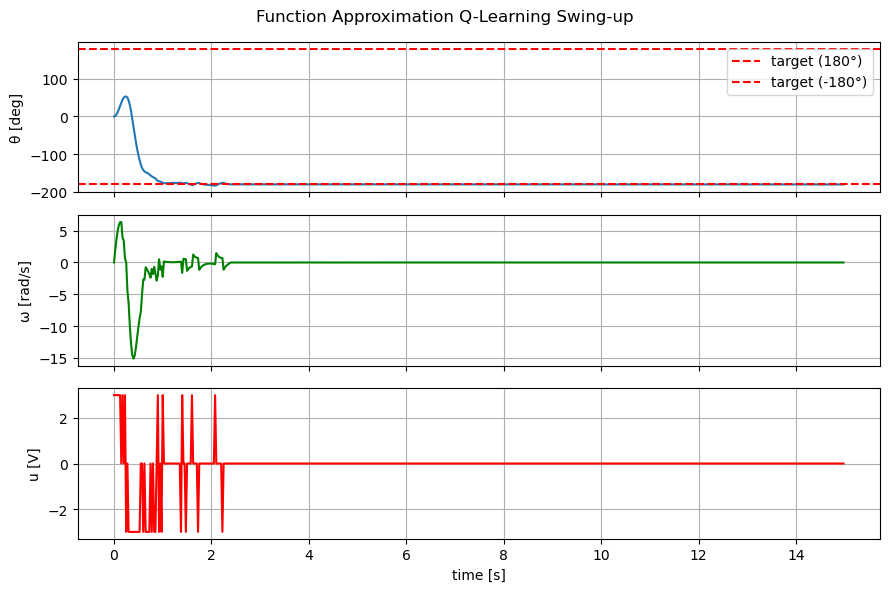

In [8]:
# Testing on simulator
# --- 2. Testing Execution ---
def test_q_simulator_fa():
    # Instantiate raw environment with the render mode flag
    base_env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, render_mode='human')
    env = CompatibilityWrapper(base_env)

    # The exact string might vary depending on the repository version you installed 
    # (e.g., 'unbalanced-disk-v0' or 'UnbalancedDisk-v0')
    # base_env = gym.make('unbalanced-disk-v0', dt=0.025, render_mode='human') 
    # env = CompatibilityWrapper(base_env)
    
    # Action definitions
    allowed_voltages = [-3.0, 0.0, 3.0]
    
    # Initialize the same feature extractor used in training
    extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)

    # Load the trained weight matrix W instead of Qmat
    try:
        with open("weights_disk160626deg0.1noise.pkl", "rb") as f:
            W = pickle.load(f)
    except FileNotFoundError:
        print("Error: 'weights_disk.pkl' not found. Run the training script first.")
        return

    obs, _ = env.reset()
    done = False
    
    obs_hist, act_hist = [], []
    step_count = 0
    # Increased test time to 15 seconds to ensure we see the full swing-up
    max_steps = 600 
    
    print("Testing FA Q-Learning on Simulator... (Will run for 15 seconds or until manually stopped)")
    
    try:
        while not done and step_count < max_steps:
            obs_hist.append(np.array(obs))
            
            # 1. Extract continuous features
            phi = extractor.get_features(obs)
            
            # 2. Calculate Q-values for all actions: Q(s, a) = phi * W
            q_values = np.dot(phi, W)
            
            # 3. Pure Exploitation: pick the action with the highest Q-value
            action_idx = np.argmax(q_values)
            u_applied = float(allowed_voltages[action_idx])
            
            act_hist.append(u_applied)
            
            # 4. Step the environment
            obs, reward, terminated, truncated, _ = env.step(u_applied)
            done = terminated or truncated
            
            env.render()
            time.sleep(1/40) # Match the 40Hz visual update
            step_count += 1
            
    except KeyboardInterrupt:
        print("\nManual stop triggered. Generating plots...")
    finally:
        env.close()

        # Generate Report Plots
        if len(obs_hist) > 0:
            obs_arr = np.array(obs_hist)
            th_deg = np.degrees(obs_arr[:, 0]) 
            omega = obs_arr[:, 1]              
            t = np.arange(len(th_deg)) * 0.025 # Adjusted to match dt=0.025s

            filename = 'ApproxQ_sim_test_data.npz'
            np.savez(filename, time=t, theta_deg=th_deg, omega_rads=omega, voltage_u=np.array(act_hist))
            print(f"Testing data saved to {filename}")
            
            fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
            
            axes[0].plot(t, th_deg)
            axes[0].axhline(180, color='r', ls='--', label='target (180°)')
            axes[0].axhline(-180, color='r', ls='--', label='target (-180°)')
            axes[0].set_ylabel('θ [deg]')
            axes[0].legend(loc='upper right')
            axes[0].grid(True)
            
            axes[1].plot(t, omega, 'g')
            axes[1].set_ylabel('ω [rad/s]')
            axes[1].grid(True)
            
            axes[2].plot(t, act_hist, 'r')
            axes[2].set_ylabel('u [V]')
            axes[2].set_xlabel('time [s]')
            axes[2].grid(True)
            
            plt.suptitle('Function Approximation Q-Learning Swing-up')
            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    test_q_simulator_fa()


# # Cell 3: Testing on simulator
# def test_q_simulator_fa():
#     dt_sim = 0.025
#     base_env = gym_unbalanced_disk.UnbalancedDisk(dt=dt_sim, render_mode='human')
#     env = CompatibilityWrapper(base_env)
    
#     # 1. ADD NOISE (To simulate the bad hardware)
#     encoder_error_deg = 5.0  
#     sigma_theta = np.radians(encoder_error_deg)
#     sigma_omega = (np.sqrt(2) / dt_sim) * sigma_theta
#     env = SensorNoiseWrapper(env, noise_std_theta=sigma_theta, noise_std_omega=sigma_omega)
    
#     # 2. ADD THE FILTER (Must go exactly here!)
#     env = LowPassFilterWrapper(env, alpha_theta=0.7, alpha_omega=0.30)
    
#     allowed_voltages = [-3.0, 0.0, 3.0]
#     extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)

#     try:
#         with open("weights_disk_robust160626.pkl", "rb") as f:
#             W = pickle.load(f)
#     except FileNotFoundError:
#         print("Error: 'weights_disk_robust.pkl' not found.")
#         return

#     # 3. NOW WE RESET. The reset will flow through the filter and noise wrappers!
#     obs, _ = env.reset()
#     done = False
    
#     obs_hist, act_hist = [], []
#     step_count = 0
#     max_steps = 600 
    
#     print("Testing FA Q-Learning on Simulator...")
    
#     try:
#         while not done and step_count < max_steps:
#             obs_hist.append(np.array(obs))
            
#             # 1. Extract continuous features
#             phi = extractor.get_features(obs)
            
#             # 2. Calculate Q-values for all actions: Q(s, a) = phi * W
#             q_values = np.dot(phi, W)
            
#             # 3. Pure Exploitation: pick the action with the highest Q-value
#             action_idx = np.argmax(q_values)
#             u_applied = float(allowed_voltages[action_idx])
            
#             act_hist.append(u_applied)
            
#             # 4. Step the environment
#             obs, reward, terminated, truncated, _ = env.step(u_applied)
#             done = terminated or truncated
            
#             env.render()
#             time.sleep(1/40) # Match the 40Hz visual update
#             step_count += 1
            
#     except KeyboardInterrupt:
#         print("\nManual stop triggered. Generating plots...")
#     finally:
#         env.close()

#         # Generate Report Plots
#         if len(obs_hist) > 0:
#             obs_arr = np.array(obs_hist)
#             th_deg = np.degrees(obs_arr[:, 0]) 
#             omega = obs_arr[:, 1]              
#             t = np.arange(len(th_deg)) * 0.025 # Adjusted to match dt=0.025s

#             filename = 'ApproxQ_sim_test_data_robust_160626.npz'
#             np.savez(filename, time=t, theta_deg=th_deg, omega_rads=omega, voltage_u=np.array(act_hist))
#             print(f"Testing data saved to {filename}")
            
#             fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
            
#             axes[0].plot(t, th_deg)
#             axes[0].axhline(180, color='r', ls='--', label='target (180°)')
#             axes[0].axhline(-180, color='r', ls='--', label='target (-180°)')
#             axes[0].set_ylabel('θ [deg]')
#             axes[0].legend(loc='upper right')
#             axes[0].grid(True)
            
#             axes[1].plot(t, omega, 'g')
#             axes[1].set_ylabel('ω [rad/s]')
#             axes[1].grid(True)
            
#             axes[2].plot(t, act_hist, 'r')
#             axes[2].set_ylabel('u [V]')
#             axes[2].set_xlabel('time [s]')
#             axes[2].grid(True)
            
#             plt.suptitle('Function Approximation Q-Learning Swing-up')
#             plt.tight_layout()
#             plt.show()

# if __name__ == "__main__":
#     test_q_simulator_fa()

## Testing on setup

Starting Hardware Execution... (Will run for 15 seconds or until manually stopped)
Press Ctrl+C to emergency stop.
Hardware environment closed safely.
Testing data saved to ApproxQ_hw_test_data.npz


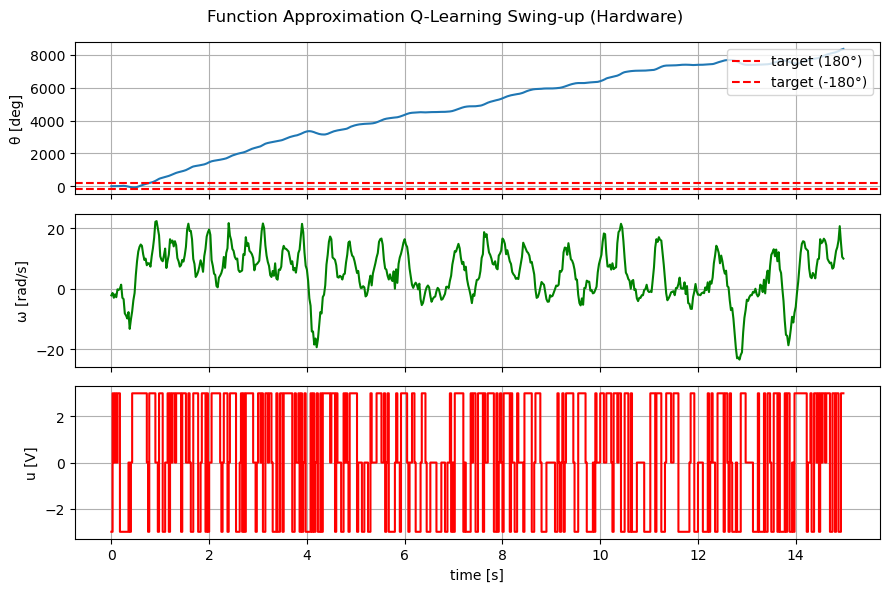

In [12]:
# # Testing on setup
# # Ensure you have your CompatibilityWrapper defined here in your notebook cell
# def run_q_hardware():
#     base_env = gym_unbalanced_disk.UnbalancedDisk_exp(umax=3.0, dt=0.05)
#     # in documentation it says dt=0.025, so might have to change simulation and hardware to that.
    
#     # Wrap it with the compatibility translator to prevent Gym version crashes
#     env = CompatibilityWrapper(base_env)
    
#     # Configuration (Must match training parameters)
#     nvec = np.array([40, 40])
#     allowed_voltages = [-3.0, -1.5, 0.0, 1.5, 3.0]
#     low = np.array([-np.pi, -40.0])  
#     high = np.array([np.pi, 40.0])

#     def discretize_physical_obs(theta, omega):
#         obs = np.array([theta, omega])
#         obs[0] = ((obs[0] + np.pi) % (2 * np.pi)) - np.pi  # Wrap angle
#         obs = np.clip(obs, low, high)
#         norm = (obs - low) / (high - low)
#         disc = np.floor(norm * nvec).astype(int)
#         disc = np.clip(disc, 0, nvec - 1)
#         return tuple(disc)

#     # Load the trained Q-table
#     try:
#         with open("q_table_disk.pkl", "rb") as f:
#             Qmat = pickle.load(f)
#     except FileNotFoundError:
#         print("Error: 'q_table_disk.pkl' not found. Run training script first.")
#         return

#     obs_hist, act_hist = [], []
#     step_count = 0
#     max_steps = 300 # 15 seconds

#     # Reset environment to get initial observation from real sensors
#     obs, info = env.reset()
#     done = False

#     print("Starting Hardware Execution... (Will run for 15 seconds or until manually stopped)")
#     print("Press Ctrl+C to emergency stop.")
    
#     try:
#         while not done and step_count < max_steps:
#             # Extract continuous physical values from the current observation
#             theta, omega = obs[0], obs[1]
            
#             # Record continuous states for plotting
#             obs_hist.append(np.array([theta, omega]))
            
#             # Discretize for the Q-table lookup mapping
#             disc_obs = discretize_physical_obs(theta, omega)
            
#             # Lookup best action index (pure exploitation)
#             action_idx = np.argmax([Qmat.get((disc_obs, a), 0.0) for a in range(len(allowed_voltages))])
#             u_applied = float(allowed_voltages[action_idx])
            
#             # Record action
#             act_hist.append(u_applied)
            
#             # Apply computed voltage to the motor and read back next state
#             obs, reward, terminated, truncated, info = env.step(u_applied)
#             done = terminated or truncated
            
#             step_count += 1
                
#     except KeyboardInterrupt:
#         print("\nEmergency Stop Triggered. Generating plots...")
#     finally:
#         # Crucial safety feature: Safely close connection and ground the real motor to 0V
#         env.close()
#         print("Hardware environment closed safely.")

#         if len(obs_hist) > 0:
#             obs_arr = np.array(obs_hist)
#             th_deg = np.degrees(obs_arr[:, 0])
#             omega = obs_arr[:, 1]
#             t = np.arange(len(th_deg)) * 0.05

#             # Saves time, theta (degrees), omega (rad/s), and applied voltage (V) arrays
#             filename = 'VanillaQ_hw_test_data100626.npz'
#             np.savez(filename, 
#                      time=t, 
#                      theta_deg=th_deg, 
#                      omega_rads=omega, 
#                      voltage_u=np.array(act_hist))
#             print(f"Testing data saved to {filename}")

#             # Generate Report Plots
#             fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
            
#             axes[0].plot(t, th_deg)
#             axes[0].axhline(180, color='r', ls='--', label='target (180°)')
#             axes[0].axhline(-180, color='r', ls='--', label='target (-180°)')
#             axes[0].set_ylabel('θ [deg]')
#             axes[0].legend(loc='upper right')
#             axes[0].grid(True)
            
#             axes[1].plot(t, omega, 'g')
#             axes[1].set_ylabel('ω [rad/s]')
#             axes[1].grid(True)
            
#             axes[2].plot(t, act_hist, 'r')
#             axes[2].set_ylabel('u [V]')
#             axes[2].set_xlabel('time [s]')
#             axes[2].grid(True)
            
#             plt.suptitle('Vanilla Q-Learning Swing-up (Hardware)')
#             plt.tight_layout()
#             plt.show()

# if __name__ == "__main__":
#     run_q_hardware()




# # Script for noisewrapper
# # Cell 4: Testing FA Q-Learning on Physical Setup
# def run_q_hardware_fa():
#     # Ensure dt matches your physical hardware specification
#     base_env = gym_unbalanced_disk.UnbalancedDisk_exp(umax=3.0, dt=0.025) 
#     env = CompatibilityWrapper(base_env)
    
#     allowed_voltages = [-3.0, 0.0, 3.0]
    
#     # Initialize the same feature extractor used in simulation
#     extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)

#     # Load the trained Function Approximation weight matrix
#     try:
#         with open("weights_disk.pkl", "rb") as f:
#             W = pickle.load(f)
#     except FileNotFoundError:
#         print("Error: 'weights_disk15062026.pkl' not found. Run training script first.")
#         return

#     obs_hist, act_hist = [], []
#     step_count = 0
#     max_steps = 600 # 15 seconds at 40Hz (dt=0.025)

#     obs, info = env.reset()
#     done = False

#     print("Starting Hardware Execution... (Will run for 15 seconds or until manually stopped)")
#     print("Press Ctrl+C to emergency stop.")
    
#     try:
#         while not done and step_count < max_steps:
#             # Record continuous states for plotting
#             obs_hist.append(np.array(obs))
            
#             # 1. Extract continuous features directly from hardware observation
#             phi = extractor.get_features(obs)
            
#             # 2. Calculate Q-values via matrix multiplication
#             q_values = np.dot(phi, W)
            
#             # 3. Pure Exploitation
#             action_idx = np.argmax(q_values)
#             u_applied = float(allowed_voltages[action_idx])
            
#             act_hist.append(u_applied)
            
#             # 4. Apply computed voltage to the motor
#             obs, reward, terminated, truncated, info = env.step(u_applied)
#             done = terminated or truncated
            
#             step_count += 1
                
#     except KeyboardInterrupt:
#         print("\nEmergency Stop Triggered. Generating plots...")
#     finally:
#         # Safely close connection and ground the real motor to 0V
#         env.close()
#         print("Hardware environment closed safely.")

#         if len(obs_hist) > 0:
#             obs_arr = np.array(obs_hist)
#             th_deg = np.degrees(obs_arr[:, 0])
#             omega = obs_arr[:, 1]
#             t = np.arange(len(th_deg)) * 0.025 # Matches dt=0.025s

#             filename = 'ApproxQ_hw_test_data.npz'
#             np.savez(filename, 
#                      time=t, 
#                      theta_deg=th_deg, 
#                      omega_rads=omega, 
#                      voltage_u=np.array(act_hist))
#             print(f"Testing data saved to {filename}")

#             fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
            
#             axes[0].plot(t, th_deg)
#             axes[0].axhline(180, color='r', ls='--', label='target (180°)')
#             axes[0].axhline(-180, color='r', ls='--', label='target (-180°)')
#             axes[0].set_ylabel('θ [deg]')
#             axes[0].legend(loc='upper right')
#             axes[0].grid(True)
            
#             axes[1].plot(t, omega, 'g')
#             axes[1].set_ylabel('ω [rad/s]')
#             axes[1].grid(True)
            
#             axes[2].step(t, act_hist, 'r', where='post')
#             axes[2].set_ylabel('u [V]')
#             axes[2].set_xlabel('time [s]')
#             axes[2].grid(True)
            
#             plt.suptitle('Function Approximation Q-Learning Swing-up (Hardware)')
#             plt.tight_layout()
#             plt.show()

# if __name__ == "__main__":
#     run_q_hardware_fa()




# Cell 4: Testing FA Q-Learning on Physical Setup
# # --- 1. Compatibility Wrapper ---
# class CompatibilityWrapper(gym.Wrapper):
#     def reset(self, *, seed=None, options=None):
#         obs = self.env.reset()
#         if not isinstance(obs, tuple):
#             return obs, {}
#         elif len(obs) == 2 and isinstance(obs[1], dict):
#             return obs
#         else:
#             return obs, {}

#     def step(self, action):
#         result = self.env.step(action)
#         if len(result) == 4:
#             obs, reward, done, info = result
#             return obs, reward, done, False, info
#         return result

# --- 3. Hardware Execution Loop ---
def run_q_hardware_fa():
    # Ensure dt matches your physical hardware specification
    base_env = gym_unbalanced_disk.UnbalancedDisk_exp(umax=3.0, dt=0.025) 
    env = CompatibilityWrapper(base_env)
    
    allowed_voltages = [-3.0, 0.0, 3.0]
    
    # Initialize the same feature extractor used in simulation
    extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)

    # Load the trained Function Approximation weight matrix
    try:
        # Fixed the filename here to match your custom naming convention
        with open("weights_disk160626deg0.1noise.pkl", "rb") as f:
            W = pickle.load(f)
    except FileNotFoundError:
        print("Error: 'weights_disk160626deg0.1noise.pkl' not found. Run training script first.")
        return

    obs_hist, act_hist = [], []
    step_count = 0
    max_steps = 600 # 15 seconds at 40Hz (dt=0.025)

    obs, info = env.reset()
    done = False

    print("Starting Hardware Execution... (Will run for 15 seconds or until manually stopped)")
    print("Press Ctrl+C to emergency stop.")
    # Insert this right before initializing your testing loops
    # env = LowPassFilterWrapper(env, alpha_theta=0.8, alpha_omega=0.15)
    # Run this. The filter will kill the chattering dead in its tracks, allowing the agent to confidently swing up even if the encoder is terrible.
    
    try:
        while not done and step_count < max_steps:
            # Record continuous states for plotting
            obs_hist.append(np.array(obs))
            
            # 1. Extract continuous features directly from hardware observation
            phi = extractor.get_features(obs)
            
            # 2. Calculate Q-values via matrix multiplication
            q_values = np.dot(phi, W)
            
            # 3. Pure Exploitation
            action_idx = np.argmax(q_values)
            u_applied = float(allowed_voltages[action_idx])
            
            act_hist.append(u_applied)
            
            # 4. Apply computed voltage to the motor
            obs, reward, terminated, truncated, info = env.step(u_applied)
            done = terminated or truncated
            
            step_count += 1
                
    except KeyboardInterrupt:
        print("\nEmergency Stop Triggered. Generating plots...")
    finally:
        # Safely close connection and ground the real motor to 0V
        env.close()
        print("Hardware environment closed safely.")

        if len(obs_hist) > 0:
            obs_arr = np.array(obs_hist)
            th_deg = np.degrees(obs_arr[:, 0])
            omega = obs_arr[:, 1]
            t = np.arange(len(th_deg)) * 0.025 # Matches dt=0.025s

            filename = 'ApproxQ_hw_test_data.npz'
            np.savez(filename, 
                     time=t, 
                     theta_deg=th_deg, 
                     omega_rads=omega, 
                     voltage_u=np.array(act_hist))
            print(f"Testing data saved to {filename}")

            fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
            
            axes[0].plot(t, th_deg)
            axes[0].axhline(180, color='r', ls='--', label='target (180°)')
            axes[0].axhline(-180, color='r', ls='--', label='target (-180°)')
            axes[0].set_ylabel('θ [deg]')
            axes[0].legend(loc='upper right')
            axes[0].grid(True)
            
            axes[1].plot(t, omega, 'g')
            axes[1].set_ylabel('ω [rad/s]')
            axes[1].grid(True)
            
            axes[2].step(t, act_hist, 'r', where='post')
            axes[2].set_ylabel('u [V]')
            axes[2].set_xlabel('time [s]')
            axes[2].grid(True)
            
            plt.suptitle('Function Approximation Q-Learning Swing-up (Hardware)')
            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    run_q_hardware_fa()

In [10]:
# Cell 4: Testing FA Q-Learning on Physical Setup
# # --- 2. Feature Extractor (Must match training exactly) ---
# class TriangularFeatureExtractor:
#     def __init__(self, n_theta=41, n_omega=31, max_omega=60.0):
#         x_th = np.linspace(-1, 1, n_theta)
#         self.c_th = np.sign(x_th) * (np.abs(x_th)**1.5) * np.pi 
        
#         # Non-linear mapping to velocity
#         x_om = np.linspace(-1, 1, n_omega)
#         self.c_om = np.sign(x_om) * (np.abs(x_om)**1.5) * max_omega
        
#         self.w_th = np.diff(self.c_th)
#         self.w_th = np.append(self.w_th, self.w_th[-1]) * 1.2 
        
#         self.w_om = np.diff(self.c_om)
#         self.w_om = np.append(self.w_om, self.w_om[-1]) * 1.2
        
#         self.n_features = n_theta * n_omega

#     def wrap_angle(self, angle):
#         return ((angle + np.pi) % (2 * np.pi)) - np.pi

#     def get_features(self, obs):
#         th_error = self.wrap_angle(obs[0] - np.pi)
#         omega = np.clip(obs[1], self.c_om[0], self.c_om[-1])
        
#         act_th = np.maximum(0, 1.0 - np.abs(th_error - self.c_th) / self.w_th)
#         act_om = np.maximum(0, 1.0 - np.abs(omega - self.c_om) / self.w_om)
        
#         features = np.outer(act_th, act_om).flatten()
#         return features

# --- 3. Hardware Execution Loop ---
def run_q_hardware_fa():
    # Ensure dt matches your physical hardware specification
    base_env = gym_unbalanced_disk.UnbalancedDisk_exp(umax=3.0, dt=0.025) 
    env = CompatibilityWrapper(base_env)
    
    allowed_voltages = [-3.0, 0.0, 3.0]
    
    # Initialize the same feature extractor used in simulation
    extractor = TriangularFeatureExtractor(n_theta=41, n_omega=31, max_omega=60.0)

    # Load the trained Function Approximation weight matrix
    try:
        # Fixed the filename here to match your custom naming convention
        with open("weights_disk160626deg0.1noise.pkl", "rb") as f:
            W = pickle.load(f)
    except FileNotFoundError:
        print("Error: 'weights_disk160626deg0.1noise.pkl' not found. Run training script first.")
        return

    obs_hist, act_hist = [], []
    step_count = 0
    max_steps = 600 # 15 seconds at 40Hz (dt=0.025)

    obs, info = env.reset()
    done = False

    print("Starting Hardware Execution... (Will run for 15 seconds or until manually stopped)")
    print("Press Ctrl+C to emergency stop.")
    
    try:
        while not done and step_count < max_steps:
            # Record continuous states for plotting
            obs_hist.append(np.array(obs))
            
            # 1. Extract continuous features directly from hardware observation
            phi = extractor.get_features(obs)
            
            # 2. Calculate Q-values via matrix multiplication
            q_values = np.dot(phi, W)
            
            # 3. Pure Exploitation
            action_idx = np.argmax(q_values)
            u_applied = float(allowed_voltages[action_idx])
            
            act_hist.append(u_applied)
            
            # 4. Apply computed voltage to the motor
            obs, reward, terminated, truncated, info = env.step(u_applied)
            done = terminated or truncated
            
            step_count += 1
                
    except KeyboardInterrupt:
        print("\nEmergency Stop Triggered. Generating plots...")
    finally:
        # Safely close connection and ground the real motor to 0V
        env.close()
        print("Hardware environment closed safely.")

        if len(obs_hist) > 0:
            obs_arr = np.array(obs_hist)
            th_deg = np.degrees(obs_arr[:, 0])
            omega = obs_arr[:, 1]
            t = np.arange(len(th_deg)) * 0.025 # Matches dt=0.025s

            filename = 'ApproxQ_hw_test_data.npz'
            np.savez(filename, 
                     time=t, 
                     theta_deg=th_deg, 
                     omega_rads=omega, 
                     voltage_u=np.array(act_hist))
            print(f"Testing data saved to {filename}")

            fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
            
            axes[0].plot(t, th_deg)
            axes[0].axhline(180, color='r', ls='--', label='target (180°)')
            axes[0].axhline(-180, color='r', ls='--', label='target (-180°)')
            axes[0].set_ylabel('θ [deg]')
            axes[0].legend(loc='upper right')
            axes[0].grid(True)
            
            axes[1].plot(t, omega, 'g')
            axes[1].set_ylabel('ω [rad/s]')
            axes[1].grid(True)
            
            axes[2].step(t, act_hist, 'r', where='post')
            axes[2].set_ylabel('u [V]')
            axes[2].set_xlabel('time [s]')
            axes[2].grid(True)
            
            plt.suptitle('Function Approximation Q-Learning Swing-up (Hardware)')
            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    run_q_hardware_fa()

USBError: [Errno None] b'libusb0-dll:err [claim_interface] could not claim interface 0, win error: The requested resource is in use.\r\n'

# Finding max $\omega$

In [4]:
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk

def estimate_max_omega():
    # Render mode included so you can watch it fall
    env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, render_mode='human')
    
    # 1. Force the pendulum to start perfectly at the top (pi)
    # Note: Depending on the specific env, you might need to bypass the reset logic
    env.reset()
    env.unwrapped.th = np.pi 
    env.unwrapped.omega = 0.0
    
    max_omega_observed = 0.0
    
    print("Applying +3V to estimate maximum angular velocity...")
    # Let it swing for a few seconds
    for _ in range(150): 
        # Apply max voltage in the direction of gravity
        obs, _, _, _, _ = env.step(3.0)
        
        current_omega = abs(obs[1])
        if current_omega > max_omega_observed:
            max_omega_observed = current_omega
            
        env.render()
        
    print(f"\n--- System Identification Complete ---")
    print(f"Absolute maximum omega reached: {max_omega_observed:.2f} rad/s")
    print(f"Recommended grid boundary (+10% margin): {max_omega_observed * 1.10:.2f} rad/s")
    
    env.close()

if __name__ == "__main__":
    estimate_max_omega()

Applying +3V to estimate maximum angular velocity...

--- System Identification Complete ---
Absolute maximum omega reached: 60.60 rad/s
Recommended grid boundary (+10% margin): 66.66 rad/s


# Exercise 6: Design Assignment Environment

In [ ]:
!pip install git+https://github.com/MaartenSchoukens/gym-unbalanced-disk@master
# in case of error try installing pyglet 
# !pip install pyglet


In [ ]:
import gymnasium as gym
import time
import gym_unbalanced_disk #is required
import numpy as np
env = gym.make('unbalanced-disk-v0',dt=0.025) #if this fails restart the kernel or use gym_unbalanced_disk.UnbalancedDisk
env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025)
# I uncommented the last env = ..., Is that the right thing to do?


In [ ]:
#if you had error just run this cell again
observation, info = env.reset()
try:
    for i in range(200):
        u = env.action_space.sample() #random input
        observation, reward, terminated, truncated, info = env.step(u) 
        print(observation, reward)
        env.render()
        time.sleep(1/24)
        if terminated or truncated:
            observation, info = env.reset()
finally: #this will always run such to close the visualization
    env.close()

    

In [ ]:
Umax = 4

# c) Input sequence
# We create an open-loop input sequence that alternates maximum control effort.
# 20 steps * 0.05s = 1.0 seconds per swing direction.
ulist = np.concatenate([
    np.full(10, Umax),   # Swing right
    np.full(10, -Umax),  # Swing left
    np.full(10, Umax),   # Swing right (building momentum)
    np.full(10, -Umax),  # Swing left  (building momentum)
]) 
# This sequence actually swings back over the top and forth over the top
obs, info = env.reset()
try:
    for u in ulist:
        obs, reward, terminated, truncated, info = env.step(u)
        print(obs,reward)
        env.render()
        time.sleep(1/24)
        if terminated or truncated:
            obs, info = env.reset()
finally: #this will always run
    env.close()
    